In [6]:
"""Proposal-faithful RQ5 artifact generator.

This script reads frozen Phase 2 raw graph outputs and generates only the
proposal-facing RQ5 artifacts in a separate reporting layer.
"""

from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns


sns.set_theme(style="whitegrid")


# Update this path in Kaggle before running.
PHASE2_INPUT_ROOT = Path("/kaggle/input/datasets/ashwinwalunj/ashwin-thesis-outputs-phase2/thesis_outputs")
OUTPUT_ROOT = Path("/kaggle/working/thesis_outputs")

RQ = "rq5"
RQ_OUTPUT_ROOT = OUTPUT_ROOT / "results_proposal" / RQ
FIGURES_ROOT = RQ_OUTPUT_ROOT / "figures"
TABLES_ROOT = RQ_OUTPUT_ROOT / "tables"
for folder in [FIGURES_ROOT, TABLES_ROOT]:
    folder.mkdir(parents=True, exist_ok=True)


def save_table(df, name):
    df.to_csv(TABLES_ROOT / f"{name}.csv", index=False)


def save_figure(fig, name):
    fig.savefig(FIGURES_ROOT / f"{name}.png", dpi=300, bbox_inches="tight")
    fig.savefig(FIGURES_ROOT / f"{name}.pdf", bbox_inches="tight")
    plt.show()


PHASE2_ARTIFACTS = PHASE2_INPUT_ROOT / "artifacts" / "phase02_graph_models"

required_files = [
    PHASE2_ARTIFACTS / "rq5_graph_variant_summary.csv",
    PHASE2_ARTIFACTS / "rq5_temporal_decay_summary.csv",
    PHASE2_ARTIFACTS / "graph_variant_metadata.csv",
    PHASE2_ARTIFACTS / "full_degree_distribution_raw.csv",
]
for path in required_files:
    if not path.exists():
        raise FileNotFoundError(f"Missing Phase 2 raw file for RQ5: {path}")


rq5_variant_df = pd.read_csv(PHASE2_ARTIFACTS / "rq5_graph_variant_summary.csv")
rq5_decay_df = pd.read_csv(PHASE2_ARTIFACTS / "rq5_temporal_decay_summary.csv")
graph_metadata_df = pd.read_csv(PHASE2_ARTIFACTS / "graph_variant_metadata.csv")
degree_dist_df = pd.read_csv(PHASE2_ARTIFACTS / "full_degree_distribution_raw.csv")

variant_label_map = {
    "cards": "Cards",
    "cards_plus_merchants": "Cards+Merchants",
    "full": "Full",
}

In [7]:
# Table 5.1 - Graph Design Ablation
table_5_1 = (
    rq5_variant_df[["GraphType", "AUC-PR", "Nodes", "Edges"]]
    .rename(columns={"GraphType": "Graph Type"})
    .sort_values("AUC-PR", ascending=False)
    .reset_index(drop=True)
)
save_table(table_5_1, "table_5_1_graph_design_ablation")

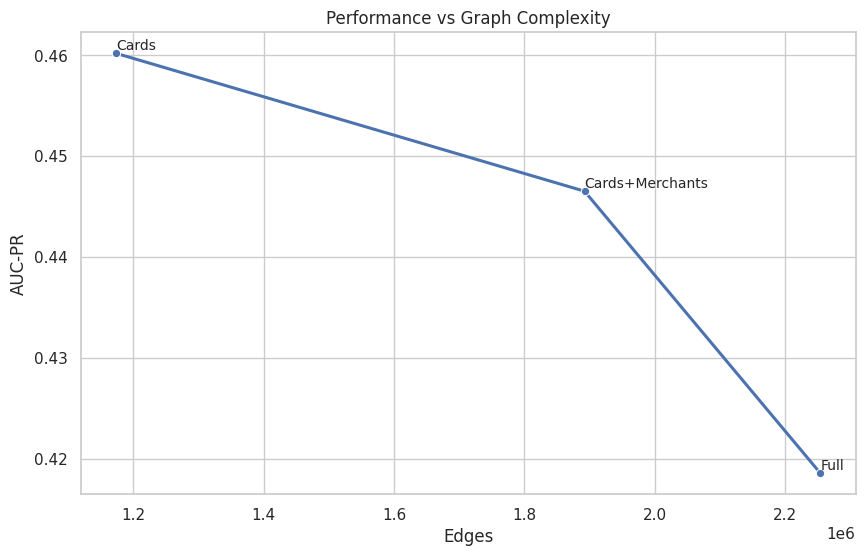

In [8]:
# Figure 5.1 - Performance vs Graph Complexity
plot_df = rq5_variant_df.copy()
fig, ax = plt.subplots(figsize=(10, 6))
sns.lineplot(
    data=plot_df.sort_values("Edges"),
    x="Edges",
    y="AUC-PR",
    marker="o",
    linewidth=2.2,
    ax=ax,
)
for _, row in plot_df.iterrows():
    label = variant_label_map.get(str(row["VariantName"]), str(row["VariantName"]))
    ax.text(row["Edges"], row["AUC-PR"], label, fontsize=10, ha="left", va="bottom")
ax.set_title("Performance vs Graph Complexity")
ax.set_xlabel("Edges")
ax.set_ylabel("AUC-PR")
save_figure(fig, "figure_5_1_performance_vs_graph_complexity")

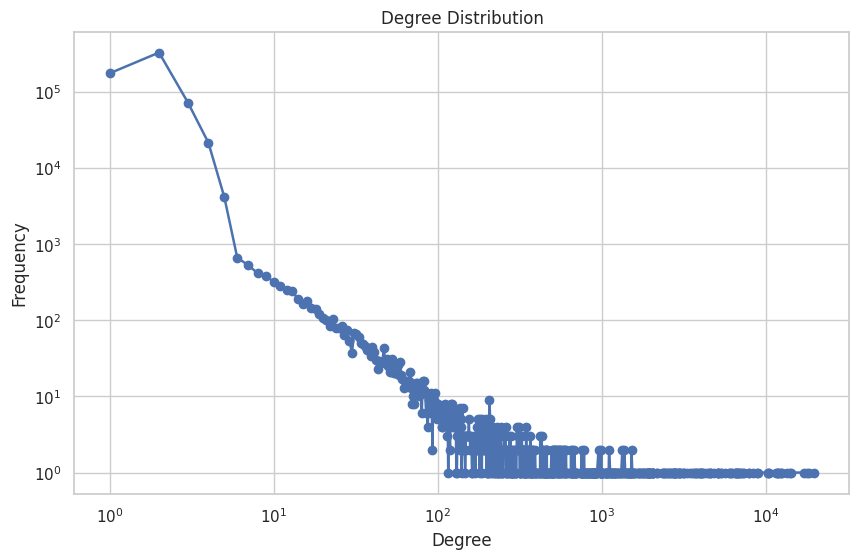

In [9]:
# Figure 5.2 - Degree Distribution
fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(degree_dist_df["degree"], degree_dist_df["frequency"], marker="o", linewidth=1.8)
ax.set_xscale("log")
ax.set_yscale("log")
ax.set_title("Degree Distribution")
ax.set_xlabel("Degree")
ax.set_ylabel("Frequency")
save_figure(fig, "figure_5_2_degree_distribution")

In [10]:
# Table 5.2 - Temporal Decay Impact
# Keep the proposal-facing lambda set in the final table.
table_5_2 = (
    rq5_decay_df[rq5_decay_df["Lambda"].isin([0.00, 0.01, 0.05])][["Lambda", "AUC-PR"]]
    .copy()
    .sort_values("Lambda")
    .reset_index(drop=True)
)
save_table(table_5_2, "table_5_2_temporal_decay_impact")